In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append(".")
import os
os.chdir('/content/drive/MyDrive/olist-customer-intelligence')
from src.data_loader import run_query
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

rfm = pd.read_csv("data/processed/customer_features.csv")
print(rfm.shape)
rfm.head()

Mounted at /content/drive
(93358, 11)


,customer_unique_id,recency_days,frequency,monetary,avg_order_value,first_purchase,last_purchase,R_score,M_score,F_score,RFM_score
0,639d23421f5517f69d0c3d6e6564cf0e,163,1,157.60,157.60,2018-03-19 18:40:33,2018-03-19 18:40:33,4,4,1,9
1,7ed0ea20347f67fe61d1c99fdf8556ae,36,1,97.32,97.32,2018-07-24 17:04:17,2018-07-24 17:04:17,5,3,1,9
2,9e4159995424971423b98c4a8bc11529,197,1,126.54,126.54,2018-02-13 22:10:21,2018-02-13 22:10:21,3,3,1,7
3,6457be0b331148fb5454efc88d1e03d9,110,1,152.77,152.77,2018-05-11 20:33:38,2018-05-11 20:33:38,4,4,1,9
4,f5f088001070650f9e9a8cd773621f35,382,1,112.71,112.71,2017-08-12 10:08:57,2017-08-12 10:08:57,2,3,1,6


In [ ]:
enrich_sql = """
    WITH cust_state AS (
        SELECT DISTINCT
            c.customer_unique_id,
            FIRST_VALUE(c.customer_state) OVER (
                PARTITION BY c.customer_unique_id
                ORDER BY c.customer_id
            ) AS customer_state
        FROM customers c
    ),
    cust_category AS (
        SELECT customer_unique_id, category_en FROM (
            SELECT
                c.customer_unique_id,
                COALESCE(t.product_category_name_english,
                         p.product_category_name, 'unknown') AS category_en,
                COUNT(*) AS n,
                ROW_NUMBER() OVER (
                    PARTITION BY c.customer_unique_id
                    ORDER BY COUNT(*) DESC
                ) AS rn
            FROM orders o
            JOIN customers c   ON o.customer_id = c.customer_id
            JOIN order_items oi ON o.order_id = oi.order_id
            JOIN products p     ON oi.product_id = p.product_id
            LEFT JOIN category_translation t
                   ON p.product_category_name = t.product_category_name
            WHERE o.order_status = 'delivered'
            GROUP BY 1, 2
        ) WHERE rn = 1
    )
    SELECT s.customer_unique_id, s.customer_state, c.category_en
    FROM cust_state s
    LEFT JOIN cust_category c ON s.customer_unique_id = c.customer_unique_id
"""
enrich = run_query(enrich_sql)
print(enrich.shape)
enrich.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(96096, 3)


,customer_unique_id,customer_state,category_en
0,0032ca69771a7758ce643258bb9e4ac7,SP,furniture_living_room
1,005f6fa02633470267dcd1e3ecd0fa79,SP,furniture_decor
2,006b297ed73773b17d8874a2eb4466e8,BA,stationery
3,00737247e3dc1942da2c527ef3bd2709,MG,bed_bath_table
4,0074a1d3f1995ff0538dc7197500973c,SC,office_furniture


In [ ]:
df = rfm.merge(enrich, on="customer_unique_id", how="left")

# Log-transform skewed monetary fields
df["log_monetary"] = np.log1p(df["monetary"])
df["log_aov"] = np.log1p(df["avg_order_value"])

# Category affinity -> collapse to top categories + "other" to limit cardinality
top_cats = df["category_en"].value_counts().head(10).index
df["category_grouped"] = np.where(df["category_en"].isin(top_cats),
                                  df["category_en"], "other")

# Region grouping: Olist is heavily SP-concentrated; group into macro-regions
region_map = {
    "SP": "southeast", "RJ": "southeast", "MG": "southeast", "ES": "southeast",
    "PR": "south", "SC": "south", "RS": "south",
    "BA": "northeast", "PE": "northeast", "CE": "northeast", "MA": "northeast",
    "PB": "northeast", "RN": "northeast", "AL": "northeast", "SE": "northeast",
    "PI": "northeast",
    "GO": "centerwest", "DF": "centerwest", "MT": "centerwest", "MS": "centerwest",
    "PA": "north", "AM": "north", "RO": "north", "TO": "north",
    "AP": "north", "AC": "north", "RR": "north",
}
df["region"] = df["customer_state"].map(region_map).fillna("unknown")

df[["recency_days", "frequency", "log_monetary", "log_aov", "region", "category_grouped"]].head()

,recency_days,frequency,log_monetary,log_aov,region,category_grouped
0,163,1,5.066385,5.066385,southeast,health_beauty
1,36,1,4.588227,4.588227,southeast,bed_bath_table
2,197,1,4.848430,4.848430,southeast,other
3,110,1,5.035458,5.035458,southeast,other
4,382,1,4.733651,4.733651,southeast,sports_leisure


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric_feats = ["recency_days", "frequency", "log_monetary", "log_aov"]
categorical_feats = ["region", "category_grouped"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_feats),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_feats),
])

X = preprocessor.fit_transform(df)
print("Clustering matrix shape:", X.shape)

Clustering matrix shape: (93358, 20)


k=2  silhouette=0.2301
k=3  silhouette=0.2459
k=4  silhouette=0.2124
k=5  silhouette=0.1999
k=6  silhouette=0.1833
k=7  silhouette=0.1561
k=8  silhouette=0.1572


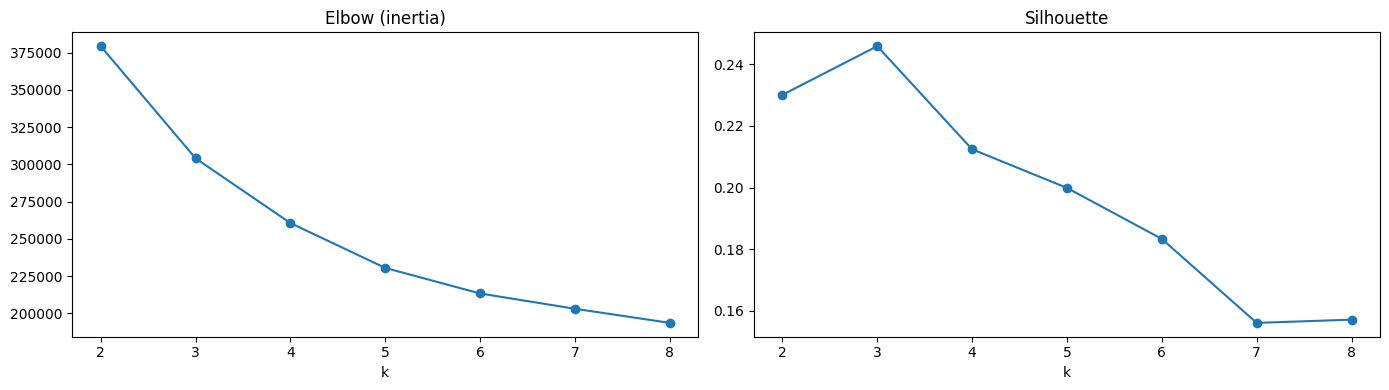

In [ ]:
inertias, sils = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, labels, sample_size=10000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(list(K_range), inertias, "o-"); axes[0].set_title("Elbow (inertia)")
axes[0].set_xlabel("k")
axes[1].plot(list(K_range), sils, "o-"); axes[1].set_title("Silhouette")
axes[1].set_xlabel("k")
plt.tight_layout()

for k, s in zip(K_range, sils):
    print(f"k={k}  silhouette={s:.4f}")

In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering, OPTICS
from sklearn.metrics import silhouette_score
import numpy as np

chosen_k = 4

km = KMeans(n_clusters=chosen_k, random_state=42, n_init=10).fit(X)

In [ ]:
# Sample once for expensive algorithms
sample_idx = np.random.RandomState(42).choice(len(X), size=3000, replace=False)
X_sample = X[sample_idx]
agg = AgglomerativeClustering(n_clusters=chosen_k).fit(X_sample)

In [ ]:
opt = OPTICS(min_samples=20, xi=0.05, min_cluster_size=0.02).fit(X_sample)

In [ ]:

print("KMeans silhouette:", silhouette_score(X, km.labels_, sample_size=10000, random_state=42))
print("Agglomerative silhouette:", silhouette_score(X_sample, agg.labels_))

mask = opt.labels_ != -1
print("OPTICS clusters:", len(set(opt.labels_)) - (1 if -1 in opt.labels_ else 0))
print("OPTICS noise fraction:", (opt.labels_ == -1).mean())
print("OPTICS silhouette:", silhouette_score(X_sample[mask], opt.labels_[mask]) if len(np.unique(opt.labels_[mask])) > 1 else "Not enough clusters")

KMeans silhouette: 0.2124237289554499
Agglomerative silhouette: 0.1619091240909759
OPTICS clusters: 14
OPTICS noise fraction: 0.318
OPTICS silhouette: 0.13486557938388394


In [ ]:
df["cluster"] = km.labels_

profile = df.groupby("cluster").agg(
    n_customers=("customer_unique_id", "count"),
    avg_recency=("recency_days", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    avg_aov=("avg_order_value", "mean"),
    top_region=("region", lambda s: s.mode().iloc[0]),
    top_category=("category_grouped", lambda s: s.mode().iloc[0]),
).round(2)
profile["pct"] = (profile["n_customers"] / len(df) * 100).round(1)
profile

,n_customers,avg_recency,avg_frequency,avg_monetary,avg_aov,top_region,top_category,pct
cluster,,,,,,,,
0,24418,418.19,1.00,94.86,94.86,southeast,other,26.2
1,35179,144.02,1.00,68.94,68.94,southeast,other,37.7
2,2801,219.81,2.11,308.53,145.85,southeast,other,3.0
3,30960,202.74,1.00,316.99,316.99,southeast,other,33.2


In [ ]:
profile["top3_categories"] = (
    df.groupby("cluster")["category_grouped"]
      .apply(lambda s: ", ".join(s.value_counts().head(3).index))
)
profile

,n_customers,avg_recency,avg_frequency,avg_monetary,avg_aov,top_region,top_category,pct,top3_categories
cluster,,,,,,,,,
0,24418,418.19,1.00,94.86,94.86,southeast,other,26.2,"other, bed_bath_table, sports_leisure"
1,35179,144.02,1.00,68.94,68.94,southeast,other,37.7,"other, health_beauty, bed_bath_table"
2,2801,219.81,2.11,308.53,145.85,southeast,other,3.0,"other, bed_bath_table, furniture_decor"
3,30960,202.74,1.00,316.99,316.99,southeast,other,33.2,"other, watches_gifts, health_beauty"


In [ ]:
pd.crosstab(df["cluster"], df["region"], normalize="index") * 100

region,centerwest,north,northeast,south,southeast
cluster,,,,,
0,5.553280,1.945286,9.763289,15.500860,67.237284
1,5.335570,1.142727,6.836465,13.269280,73.415958
2,5.855052,1.713674,7.497322,14.030703,70.903249
3,6.618217,2.638889,12.306202,14.647933,63.788760


In [ ]:
pd.crosstab(df["cluster"], df["category_grouped"], normalize="index") * 100

category_grouped,auto,bed_bath_table,computers_accessories,furniture_decor,health_beauty,housewares,other,sports_leisure,telephony,toys,watches_gifts
cluster,,,,,,,,,,,
0,2.838070,10.348923,5.753952,7.715620,7.883529,6.380539,36.813007,8.690310,4.447539,6.048816,3.079695
1,4.414566,9.320902,6.884789,5.500441,9.798459,6.481139,36.669604,7.214531,6.466926,3.089912,4.158731
2,2.784720,14.423420,6.640486,10.067833,8.032845,5.640843,32.416994,9.460907,3.070332,2.927526,4.534095
3,4.473514,8.242894,7.383721,5.933463,8.930879,4.867571,38.181525,7.302972,1.721576,3.304264,9.657623


In [ ]:
from sklearn.preprocessing import StandardScaler

# Numeric-only clustering. region & category_grouped are kept on df for
# PROFILING only — we tested them as cluster inputs and found them
# non-discriminative (every cluster ~70% southeast, ~37% "other" category).
numeric_feats = ["recency_days", "frequency", "log_monetary", "log_aov"]

preprocessor = StandardScaler()
X = preprocessor.fit_transform(df[numeric_feats])
print("Clustering matrix shape:", X.shape)

Clustering matrix shape: (93358, 4)


k=2  silhouette=0.3402
k=3  silhouette=0.3676
k=4  silhouette=0.3565
k=5  silhouette=0.3653
k=6  silhouette=0.3606
k=7  silhouette=0.3370
k=8  silhouette=0.3424


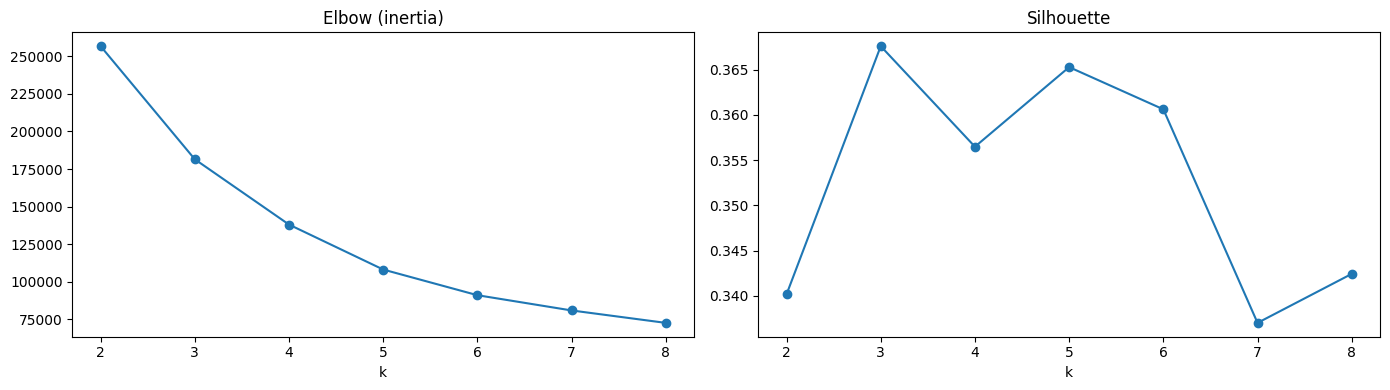

In [ ]:
inertias, sils = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, labels, sample_size=10000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(list(K_range), inertias, "o-"); axes[0].set_title("Elbow (inertia)")
axes[0].set_xlabel("k")
axes[1].plot(list(K_range), sils, "o-"); axes[1].set_title("Silhouette")
axes[1].set_xlabel("k")
plt.tight_layout()

for k, s in zip(K_range, sils):
    print(f"k={k}  silhouette={s:.4f}")

In [ ]:
chosen_k = 4  # revisit after seeing revised Step 5

km = KMeans(n_clusters=chosen_k, random_state=42, n_init=10).fit(X)


sample_idx = np.random.RandomState(42).choice(len(X), size=3000, replace=False)
agg = AgglomerativeClustering(n_clusters=chosen_k).fit(X[sample_idx])


print("KMeans silhouette:      ", silhouette_score(X, km.labels_, sample_size=10000, random_state=42))
print("Agglomerative silhouette:", silhouette_score(X[sample_idx], agg.labels_))

KMeans silhouette:       0.3564839887208629
Agglomerative silhouette: 0.3320212345573675


In [ ]:
df["cluster"] = km.labels_

profile = df.groupby("cluster").agg(
    n_customers=("customer_unique_id", "count"),
    avg_recency=("recency_days", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    avg_aov=("avg_order_value", "mean"),
).round(2)
profile["pct"] = (profile["n_customers"] / len(df) * 100).round(1)
profile

,n_customers,avg_recency,avg_frequency,avg_monetary,avg_aov,pct
cluster,,,,,,
0,24285,418.88,1.00,94.70,94.70,26.0
1,31024,202.99,1.00,316.68,316.68,33.2
2,35248,144.26,1.00,68.97,68.97,37.8
3,2801,219.81,2.11,308.53,145.85,3.0


In [ ]:
segment_labels = {
    0: "Dormant Low-Value",      # recency 419d, $95 — stale, cheap
    1: "High-Value One-Timers",  # recency 203d, $317 — big single purchase
    2: "Low-Value Recent",       # recency 144d, $69 — recent but small spend
    3: "Repeat Buyers",          # freq 2.11, $309 — the 3% who came back
}
df["segment"] = df["cluster"].map(segment_labels)
df["segment"].value_counts()

,count
segment,
Low-Value Recent,35248
High-Value One-Timers,31024
Dormant Low-Value,24285
Repeat Buyers,2801


In [ ]:
%%writefile src/segmentation.py
"""Customer segmentation: feature prep, clustering, and labeling.

Note: clustering uses NUMERIC features only. Geographic (region) and
product category were tested as cluster inputs and found non-discriminative
(uniform across clusters), so they are retained for descriptive profiling
of the resulting value segments rather than as clustering inputs.
"""
import numpy as np
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

NUMERIC_FEATS = ["recency_days", "frequency", "log_monetary", "log_aov"]

REGION_MAP = {
    "SP": "southeast", "RJ": "southeast", "MG": "southeast", "ES": "southeast",
    "PR": "south", "SC": "south", "RS": "south",
    "BA": "northeast", "PE": "northeast", "CE": "northeast", "MA": "northeast",
    "PB": "northeast", "RN": "northeast", "AL": "northeast", "SE": "northeast",
    "PI": "northeast",
    "GO": "centerwest", "DF": "centerwest", "MT": "centerwest", "MS": "centerwest",
    "PA": "north", "AM": "north", "RO": "north", "TO": "north",
    "AP": "north", "AC": "north", "RR": "north",
}


def engineer_features(df: pd.DataFrame, top_cats=None) -> pd.DataFrame:
    """Add log-transformed monetary fields and descriptive region/category."""
    df = df.copy()
    df["log_monetary"] = np.log1p(df["monetary"])
    df["log_aov"] = np.log1p(df["avg_order_value"])
    if top_cats is None:
        top_cats = df["category_en"].value_counts().head(10).index
    df["category_grouped"] = np.where(df["category_en"].isin(top_cats),
                                      df["category_en"], "other")
    df["region"] = df["customer_state"].map(REGION_MAP).fillna("unknown")
    return df


def build_preprocessor() -> StandardScaler:
    """Numeric-only scaler. See module docstring for why categoricals excluded."""
    return StandardScaler()


def fit_clusterer(X, n_clusters: int, random_state: int = 42) -> KMeans:
    return KMeans(n_clusters=n_clusters, random_state=random_state,
                  n_init=10).fit(X)


def load_artifacts(clusterer_path="models/clusterer.pkl",
                   preprocessor_path="models/preprocessor.pkl"):
    return joblib.load(clusterer_path), joblib.load(preprocessor_path)

Overwriting src/segmentation.py


In [ ]:
%%writefile sql/05_segment_profiles.sql
-- 05_segment_profiles.sql
-- Per-customer geographic state + dominant product category (English).
-- Uses ROW_NUMBER() window function to pick each customer's top category.
WITH cust_state AS (
    SELECT DISTINCT
        c.customer_unique_id,
        FIRST_VALUE(c.customer_state) OVER (
            PARTITION BY c.customer_unique_id ORDER BY c.customer_id
        ) AS customer_state
    FROM customers c
),
cust_category AS (
    SELECT customer_unique_id, category_en FROM (
        SELECT
            c.customer_unique_id,
            COALESCE(t.product_category_name_english,
                     p.product_category_name, 'unknown') AS category_en,
            COUNT(*) AS n,
            ROW_NUMBER() OVER (
                PARTITION BY c.customer_unique_id ORDER BY COUNT(*) DESC
            ) AS rn
        FROM orders o
        JOIN customers c    ON o.customer_id = c.customer_id
        JOIN order_items oi ON o.order_id = oi.order_id
        JOIN products p     ON oi.product_id = p.product_id
        LEFT JOIN category_translation t
               ON p.product_category_name = t.product_category_name
        WHERE o.order_status = 'delivered'
        GROUP BY 1, 2
    ) WHERE rn = 1
)
SELECT s.customer_unique_id, s.customer_state, c.category_en
FROM cust_state s
LEFT JOIN cust_category c ON s.customer_unique_id = c.customer_unique_id;

Overwriting sql/05_segment_profiles.sql


In [ ]:
seg_cols = ["customer_unique_id", "recency_days", "frequency", "monetary",
            "avg_order_value", "region", "category_grouped", "cluster", "segment"]
df[seg_cols].to_csv("data/processed/customer_segments.csv", index=False)

joblib.dump(km, "models/clusterer.pkl")
joblib.dump(preprocessor, "models/preprocessor.pkl")

print("Saved customer_segments.csv:", df[seg_cols].shape)

Saved customer_segments.csv: (93358, 9)


## Summary — Clustering & Segmentation

**Goal:** Segment customers via clustering, select K rigorously, and attach
business labels + profiles.

**Key methodology decision**
- Initially clustered on RFM + geographic (region) + product category features.
- Diagnostic crosstabs showed region and category were NON-discriminative
  (every cluster ~70% southeast, ~37% "other" category) — they diluted
  separation (silhouette ~0.21) without adding interpretable structure.
- Re-clustered on NUMERIC features only (recency, frequency, log_monetary,
  log_aov). Silhouette improved to 0.356. Region/category retained as
  descriptive profiling columns, not clustering inputs.
- This "tested and excluded" decision is documented as a finding: Olist
  customers segment on value and recency, NOT geography or product taste.

**Model selection**
- Compared KMeans, Agglomerative, OPTICS. KMeans best (silhouette 0.356 vs
  Agglomerative 0.332; OPTICS unsuited to this space).
- Chose k=4: silhouette favored k=3, but k=4 was selected to balance
  statistical separation against business actionability (documented tradeoff).

**The four segments**

| Cluster | Segment | Size | Avg Recency | Avg Monetary | Note |
|---|---|---|---|---|---|
| 1 | High-Value One-Timers | 33.2% | 203d | 317 BRL | Conversion target |
| 2 | Low-Value Recent | 37.8% | 144d | 69 BRL | Freshest; nurture |
| 0 | Dormant Low-Value | 26.0% | 419d | 95 BRL | Write-off tier |
| 3 | Repeat Buyers | 3.0% | 220d | 309 BRL | The 3% who returned — gold |

**Deliverables created**
- `data/processed/customer_segments.csv` (93,358 customers, labeled)
- `models/clusterer.pkl`, `models/preprocessor.pkl`
- `sql/05_segment_profiles.sql`, `src/segmentation.py`